# nyc311 SDK Quickstart

This notebook starts with the simplest possible workflow, then layers on more advanced analysis.

Setup for local use:
- run `uv sync --extra science --group notebooks`
- select the project `.venv` / `nyc311` kernel in Jupyter or VS Code

Levels in this notebook:
1. load a packaged sample and inspect it as a DataFrame
2. extract and aggregate complaint topics
3. inspect resolution gaps
4. audit topic coverage so `other` is visible
5. add custom rules for a new complaint type
6. score anomalies and render a notebook-native report summary

You can stop after any section and still have a useful, working workflow.

In [10]:
from datetime import date
from types import SimpleNamespace

from IPython.display import Markdown, display

from nyc311 import (
    analysis,
    dataframes,
    export,
    geographies,
    io,
    models,
    pipeline,
    plotting,
    samples,
    spatial,
)

nyc311 = SimpleNamespace(
    AnalysisWindow=models.AnalysisWindow,
    BOROUGH_BROOKLYN=models.BOROUGH_BROOKLYN,
    ExportTarget=models.ExportTarget,
    GeographyFilter=models.GeographyFilter,
    ServiceRequestFilter=models.ServiceRequestFilter,
    ServiceRequestRecord=models.ServiceRequestRecord,
    SocrataConfig=models.SocrataConfig,
    TopicQuery=models.TopicQuery,
    aggregate_by_geography=analysis.aggregate_by_geography,
    analyze_resolution_gaps=analysis.analyze_resolution_gaps,
    analyze_topic_coverage=analysis.analyze_topic_coverage,
    detect_anomalies=analysis.detect_anomalies,
    extract_topics=analysis.extract_topics,
    supported_topic_queries=models.supported_topic_queries,
    records_to_dataframe=dataframes.records_to_dataframe,
    assignments_to_dataframe=dataframes.assignments_to_dataframe,
    summaries_to_dataframe=dataframes.summaries_to_dataframe,
    gaps_to_dataframe=dataframes.gaps_to_dataframe,
    anomalies_to_dataframe=dataframes.anomalies_to_dataframe,
    coverage_to_dataframe=dataframes.coverage_to_dataframe,
    dataframe_to_records=dataframes.dataframe_to_records,
    export_service_requests_csv=export.export_service_requests_csv,
    export_report_card=export.export_report_card,
    export_topic_table=export.export_topic_table,
    export_geojson=export.export_geojson,
    load_sample_service_requests=samples.load_sample_service_requests,
    load_sample_boundaries=samples.load_sample_boundaries,
    load_nyc_boundaries=geographies.load_nyc_boundaries,
    load_nyc_boundaries_geodataframe=geographies.load_nyc_boundaries_geodataframe,
    boundaries_to_dataframe=geographies.boundaries_to_dataframe,
    boundaries_to_geojson=geographies.boundaries_to_geojson,
    clip_boundaries_to_bbox=geographies.clip_boundaries_to_bbox,
    spatially_enrich_records=geographies.spatially_enrich_records,
    plot_boundary_choropleth=plotting.plot_boundary_choropleth,
    plot_boundary_preview=plotting.plot_boundary_preview,
    load_service_requests=io.load_service_requests,
    fetch_service_requests=pipeline.fetch_service_requests,
    run_topic_pipeline=pipeline.run_topic_pipeline,
    load_boundaries=geographies.load_boundaries,
    load_boundaries_geodataframe=spatial.load_boundaries_geodataframe,
    records_to_geodataframe=spatial.records_to_geodataframe,
    spatial_join_records_to_boundaries=spatial.spatial_join_records_to_boundaries,
    summaries_to_geodataframe=spatial.summaries_to_geodataframe,
    normalize_borough_name=models.normalize_borough_name,
)

records = nyc311.load_sample_service_requests(
    filters=nyc311.ServiceRequestFilter(
        start_date=date(2025, 1, 1),
        end_date=date(2025, 1, 31),
        geography=nyc311.GeographyFilter(geography="borough", value="BROOKLYN"),
        complaint_types=("Noise - Residential",),
    )
)

records_df = nyc311.records_to_dataframe(records)

In [11]:
print(f"Found {len(records)} records")

records_df.head()

Found 4 records


,service_request_id,created_date,complaint_type,descriptor,borough,community_district,resolution_description,latitude,longitude
0,1001,2025-01-05,Noise - Residential,Loud party music after midnight,BROOKLYN,BROOKLYN 01,Officers advised occupants to lower music,40.730,-73.960
1,1002,2025-01-07,Noise - Residential,Banging and hammering from upstairs apartment,BROOKLYN,BROOKLYN 01,Condition resolved after inspection,40.730,-73.960
2,1003,2025-01-11,Noise - Residential,Construction drilling started before 7am,BROOKLYN,BROOKLYN 03,Referred to construction enforcement,40.685,-73.935
3,1004,2025-01-17,Noise - Residential,Dog barking continuously in rear yard,BROOKLYN,BROOKLYN 03,Caller advised to document recurrence,40.685,-73.935


In [12]:
records_df[
    [
        "service_request_id",
        "created_date",
        "complaint_type",
        "descriptor",
        "borough",
        "community_district",
    ]
].head(10)

,service_request_id,created_date,complaint_type,descriptor,borough,community_district
0,1001,2025-01-05,Noise - Residential,Loud party music after midnight,BROOKLYN,BROOKLYN 01
1,1002,2025-01-07,Noise - Residential,Banging and hammering from upstairs apartment,BROOKLYN,BROOKLYN 01
2,1003,2025-01-11,Noise - Residential,Construction drilling started before 7am,BROOKLYN,BROOKLYN 03
3,1004,2025-01-17,Noise - Residential,Dog barking continuously in rear yard,BROOKLYN,BROOKLYN 03


,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,is_dominant_topic
0,community_district,BROOKLYN 01,Noise - Residential,banging,1,2,0.5,1,True
2,community_district,BROOKLYN 03,Noise - Residential,construction,1,2,0.5,1,True


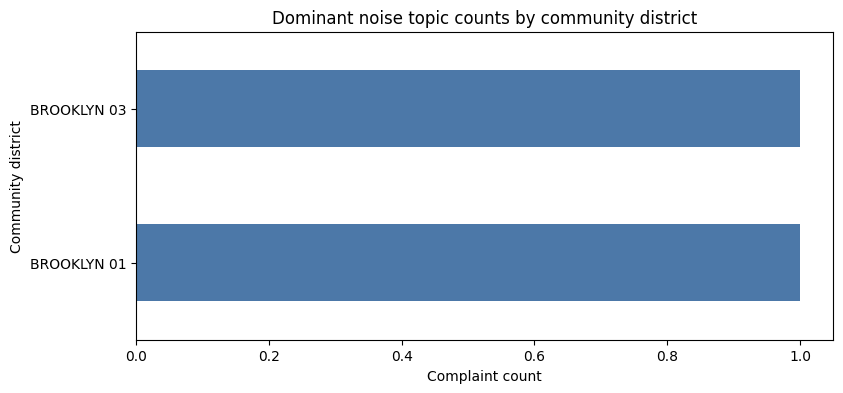

In [13]:
assignments = nyc311.extract_topics(
    records,
    nyc311.TopicQuery("Noise - Residential", top_n=10),
)
summaries = nyc311.aggregate_by_geography(
    assignments,
    geography="community_district",
)
summaries_df = nyc311.summaries_to_dataframe(summaries)

dominant_topics_df = summaries_df[summaries_df["is_dominant_topic"]].sort_values(
    ["complaint_count", "share_of_geography"],
    ascending=[False, False],
)
display(dominant_topics_df.head(10))

plot_df = dominant_topics_df.head(10).sort_values("complaint_count")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="geography_value",
        y="complaint_count",
        figsize=(9, 4),
        color="#4C78A8",
        legend=False,
        title="Dominant noise topic counts by community district",
    )
    ax.set_xlabel("Complaint count")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(plot_df[["geography_value", "topic", "complaint_count"]])

,geography,geography_value,complaint_type,total_request_count,resolved_request_count,unresolved_request_count,unresolved_share,resolution_rate
0,borough,BROOKLYN,Noise - Residential,4,4,0,0.0,1.0


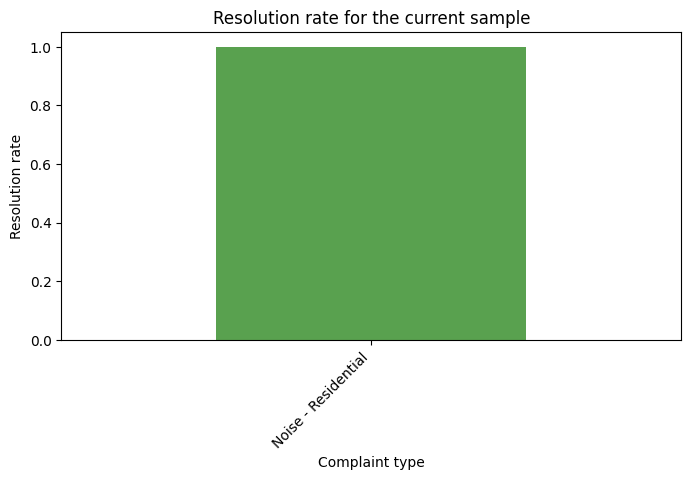

In [14]:
resolution_summaries = nyc311.analyze_resolution_gaps(
    records,
    [record for record in records if record.resolution_description is not None],
)
resolution_df = nyc311.gaps_to_dataframe(resolution_summaries)
display(resolution_df.head(10))

try:
    import matplotlib.pyplot as plt

    ax = resolution_df.head(10).plot.bar(
        x="complaint_type",
        y="resolution_rate",
        figsize=(8, 4),
        color="#59A14F",
        legend=False,
        title="Resolution rate for the current sample",
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Resolution rate")
    ax.set_xlabel("Complaint type")
    plt.xticks(rotation=45, ha="right")
    plt.show()
except ImportError:
    display(resolution_df[["complaint_type", "resolution_rate"]].head(10))

In [15]:
coverage = nyc311.analyze_topic_coverage(
    records,
    nyc311.TopicQuery("Noise - Residential", top_n=10),
)
coverage_df = nyc311.coverage_to_dataframe([coverage])
display(coverage_df)

display(
    Markdown(
        "\n".join(
            [
                "### Coverage Audit",
                f"- Matched records: {coverage.matched_records}/{coverage.total_records}",
                f"- Coverage rate: {coverage.coverage_rate:.1%}",
                f"- Top unmatched descriptors: {list(coverage.top_unmatched_descriptors) or 'None'}",
            ]
        )
    )
)

,complaint_type,total_records,matched_records,other_records,coverage_rate,top_unmatched_descriptors
0,Noise - Residential,4,4,0,1.0,[]


### Coverage Audit
- Matched records: 4/4
- Coverage rate: 100.0%
- Top unmatched descriptors: None

In [16]:
custom_rules = (
    ("hydrant_issue", ("hydrant", "low water pressure")),
    ("leak", ("leak", "leaking")),
)

water_records = [
    nyc311.ServiceRequestRecord(
        service_request_id="demo-1",
        created_date=date(2025, 1, 1),
        complaint_type="Water System",
        descriptor="Low water pressure near hydrant",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
    nyc311.ServiceRequestRecord(
        service_request_id="demo-2",
        created_date=date(2025, 1, 2),
        complaint_type="Water System",
        descriptor="Leaking hydrant on corner",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
    nyc311.ServiceRequestRecord(
        service_request_id="demo-3",
        created_date=date(2025, 1, 3),
        complaint_type="Water System",
        descriptor="Pressure issue in building basement",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
]

before_custom_rules = nyc311.analyze_topic_coverage(
    water_records,
    nyc311.TopicQuery("Water System", top_n=10),
)
after_custom_rules = nyc311.analyze_topic_coverage(
    water_records,
    nyc311.TopicQuery("Water System", top_n=10),
    custom_rules=custom_rules,
)
nyc311.coverage_to_dataframe([before_custom_rules, after_custom_rules])

,complaint_type,total_records,matched_records,other_records,coverage_rate,top_unmatched_descriptors
0,Water System,3,3,0,1.000000,[]
1,Water System,3,2,1,0.666667,"[(Pressure issue in building basement, 1)]"


/Users/blaise/Desktop/blaise-oss/nyc311/src/nyc311/analytics.py:94: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = zscore(values)


## Sample Report Card
- Sample size: 4 records
- Dominant districts shown above: 2
- Topic coverage: 100.0%
- Anomalies above threshold: 0

,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,z_score,is_anomaly,window_days,anomaly_threshold
0,community_district,BROOKLYN 01,Noise - Residential,banging,1,2,0.5,1,0.0,False,30,1.5
1,community_district,BROOKLYN 01,Noise - Residential,party_music,1,2,0.5,2,0.0,False,30,1.5
2,community_district,BROOKLYN 03,Noise - Residential,construction,1,2,0.5,1,0.0,False,30,1.5
3,community_district,BROOKLYN 03,Noise - Residential,pet_noise,1,2,0.5,2,0.0,False,30,1.5


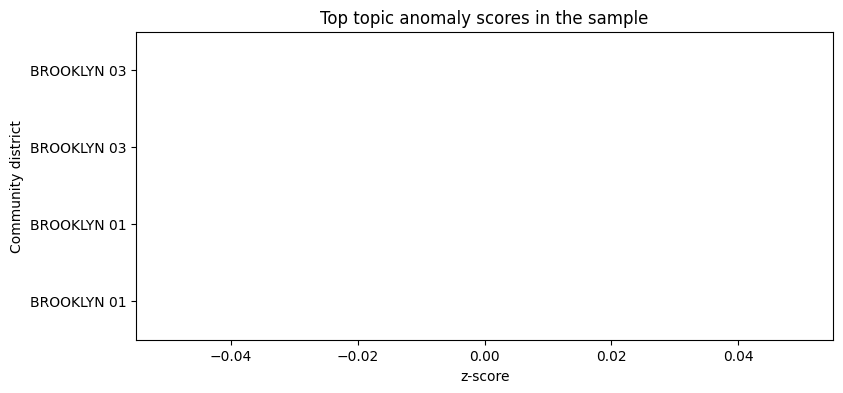

In [17]:
anomalies = nyc311.detect_anomalies(
    summaries,
    nyc311.AnalysisWindow(days=30),
    z_threshold=1.5,
)
anomalies_df = nyc311.anomalies_to_dataframe(anomalies)

display(
    Markdown(
        "\n".join(
            [
                "## Sample Report Card",
                f"- Sample size: {len(records)} records",
                f"- Dominant districts shown above: {len(dominant_topics_df)}",
                f"- Topic coverage: {coverage.coverage_rate:.1%}",
                f"- Anomalies above threshold: {int(anomalies_df['is_anomaly'].sum())}",
            ]
        )
    )
)

display(anomalies_df.head(10))

plot_df = anomalies_df.head(10).sort_values("z_score")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="geography_value",
        y="z_score",
        figsize=(9, 4),
        color="#E15759",
        legend=False,
        title="Top topic anomaly scores in the sample",
    )
    ax.set_xlabel("z-score")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(plot_df[["geography_value", "topic", "z_score", "is_anomaly"]])

In [18]:
# Optional: persist data or summaries later.
# The notebook intentionally renders tables and markdown inline first.
#
# nyc311.export_service_requests_csv(
#     records,
#     nyc311.ExportTarget("csv", "brooklyn-noise-snapshot.csv"),
# )
#
# nyc311.export_topic_table(
#     summaries,
#     nyc311.ExportTarget("csv", "brooklyn-noise-topics.csv"),
# )
#
# nyc311.export_anomalies(
#     anomalies,
#     nyc311.ExportTarget("csv", "brooklyn-noise-anomalies.csv"),
# )